# IR Final Model — `ir_dset_final` Results

Complete evaluation of the final IR drone detection model trained on `ir_dset_final` (129,130 images, 13 sources).

In [1]:
import json, os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import matplotlib.ticker as mticker
from pathlib import Path
from IPython.display import display, HTML, Image

RUNS_DIR = Path("../runs")
RUN_NAME = "IR_FT_final_cleaned_s0"
FIGS_DIR = Path("figures")
FIGS_DIR.mkdir(exist_ok=True)

plt.rcParams.update({
    'figure.figsize': (12, 6), 'font.size': 11, 'font.family': 'serif',
    'axes.titlesize': 13, 'axes.labelsize': 11, 'legend.fontsize': 9,
    'figure.dpi': 150, 'savefig.bbox': 'tight', 'savefig.dpi': 200,
    'axes.grid': True, 'grid.alpha': 0.3,
})

print(f"Run: {RUN_NAME}")
print(f"Runs directory: {RUNS_DIR.resolve()}")

Run: IR_FT_final_cleaned_s0
Runs directory: C:\Users\User\Desktop\UNISA projects\Drone detection\es proj 3 thesis workspace\ES_Drone_Detection\runs


---
## 1. Dataset Overview — `ir_dset_final`

The final IR drone detection dataset, built from 13 sources (8 from dsetV6 + CST Anti-UAV + crop-zoom augmentation + 3 negative-only sources).

In [2]:
# === Dataset Statistics ===

split_data = {
    'Split': ['Train', 'Val', 'Test', 'Total'],
    'Images': [107809, 11709, 9612, 129130],
    'Positive': [79999, 7414, 6257, 93670],
    'Negative': [27810, 4295, 3355, 35460],
    'Neg %': ['25.8%', '36.7%', '34.9%', '27.5%'],
}
df_splits = pd.DataFrame(split_data).set_index('Split')

 
print('  Dataset Split Distribution')
 
display(df_splits.style
    .format({'Images': '{:,}', 'Positive': '{:,}', 'Negative': '{:,}'})
    .set_properties(**{'text-align': 'center'}))

  Dataset Split Distribution


,Images,Positive,Negative,Neg %
Split,,,,
Train,"107,809","79,999","27,810",25.8%
Val,"11,709","7,414","4,295",36.7%
Test,"9,612","6,257","3,355",34.9%
Total,"129,130","93,670","35,460",27.5%


In [3]:
#  Per-Source Image Counts 

source_data = [
    ('3rd Anti-UAV',   32132, 29140, 2992, 'Positive'),
    ('CST Anti-UAV',   22957, 21397, 1560, 'Positive'),
    ('Svanstr\u00f6m',      21637, 14956, 6681, 'Positive + Hard Neg'),
    ('Small Objects',  11246,  9966, 1280, 'Positive'),
    ('Crop-Zoom',       9808,  9808,    0, 'Augmentation'),
    ('Sea',             8398,     0, 8398, 'Negative'),
    ('FLIR',            6360,     0, 6360, 'Negative'),
    ('Overhead',        5764,     0, 5764, 'Negative'),
    ('Gold V2',         3687,  3399,  288, 'Positive'),
    ('May22',           2411,  2058,  353, 'Positive'),
    ('Roboflow',        2269,  2189,   80, 'Positive'),
    ('Bird',            1582,     0, 1582, 'Negative'),
    ('Other',            694,   572,  122, 'Positive'),
    ('DroneDetect IR',   185,   185,    0, 'Positive'),
]

df_sources = pd.DataFrame(source_data, columns=['Source', 'Images', 'Positive', 'Negative', 'Type'])
df_sources = df_sources.set_index('Source')

totals = pd.DataFrame([{
    'Source': 'TOTAL',
    'Images': df_sources['Images'].sum(),
    'Positive': df_sources['Positive'].sum(),
    'Negative': df_sources['Negative'].sum(),
    'Type': '',
}]).set_index('Source')
df_display = pd.concat([df_sources, totals])

 
print('  Per-Source Image Counts')
 
display(df_display.style
    .format({'Images': '{:,}', 'Positive': '{:,}', 'Negative': '{:,}'})
    .set_properties(**{'text-align': 'center'}))

  Per-Source Image Counts


,Images,Positive,Negative,Type
Source,,,,
3rd Anti-UAV,"32,132","29,140","2,992",Positive
CST Anti-UAV,"22,957","21,397","1,560",Positive
Svanström,"21,637","14,956","6,681",Positive + Hard Neg
Small Objects,"11,246","9,966","1,280",Positive
Crop-Zoom,"9,808","9,808",0,Augmentation
Sea,"8,398",0,"8,398",Negative
FLIR,"6,360",0,"6,360",Negative
Overhead,"5,764",0,"5,764",Negative
Gold V2,"3,687","3,399",288,Positive


In [4]:
#  Drone Size Bucket Summary 

size_data = {
    'Bucket': ['Tiny (<20\u00d720)', 'Small (20-50)', 'Medium (50-128)', 'Large (>128)'],
    'Count': [34523, 38813, 13076, 7730],
}
df_sizes = pd.DataFrame(size_data).set_index('Bucket')
df_sizes['Percentage'] = (df_sizes['Count'] / df_sizes['Count'].sum() * 100).round(1)

 
print('  Drone Size Bucket Summary (annotations)')
 
display(df_sizes.style
    .format({'Count': '{:,}', 'Percentage': '{:.1f}%'})
    .set_properties(**{'text-align': 'center'})
    .bar(subset=['Percentage'], color='#4CAF50', vmin=0, vmax=50))



  Drone Size Bucket Summary (annotations)


,Count,Percentage
Bucket,,
Tiny (<20×20),"34,523",36.7%
Small (20-50),"38,813",41.2%
Medium (50-128),"13,076",13.9%
Large (>128),"7,730",8.2%


  Sample Images per Source (with GT bounding boxes)


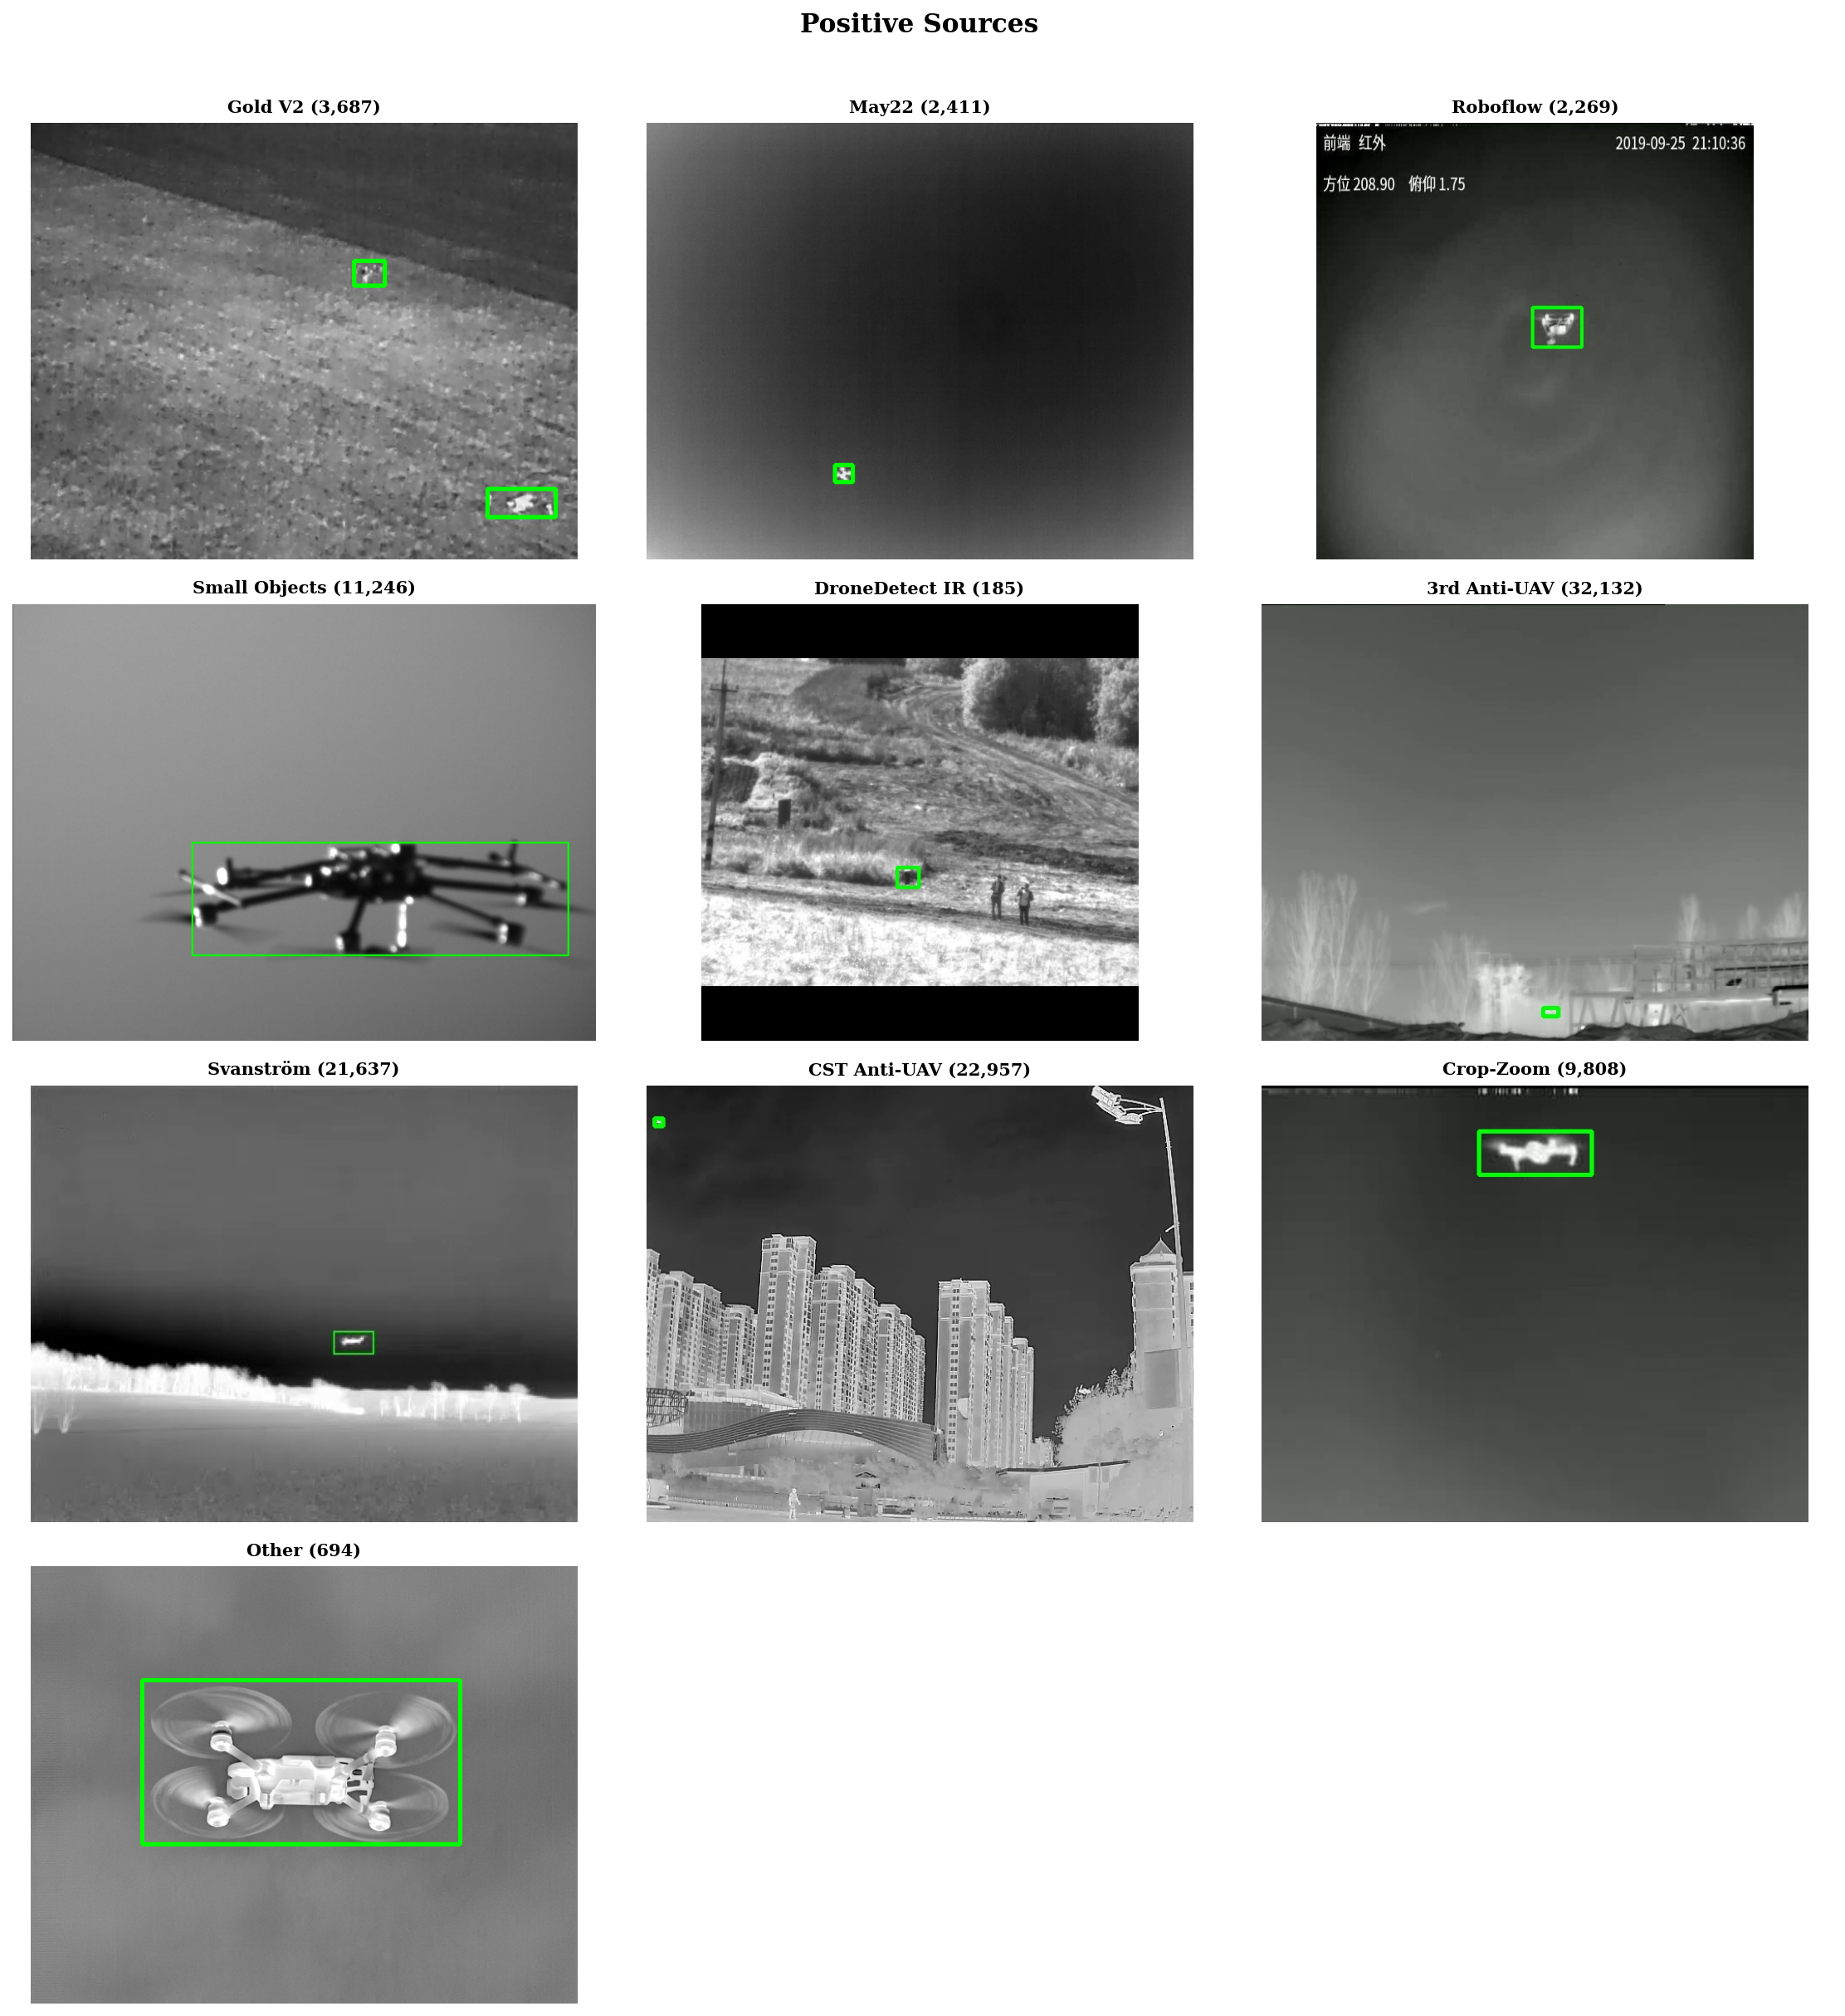

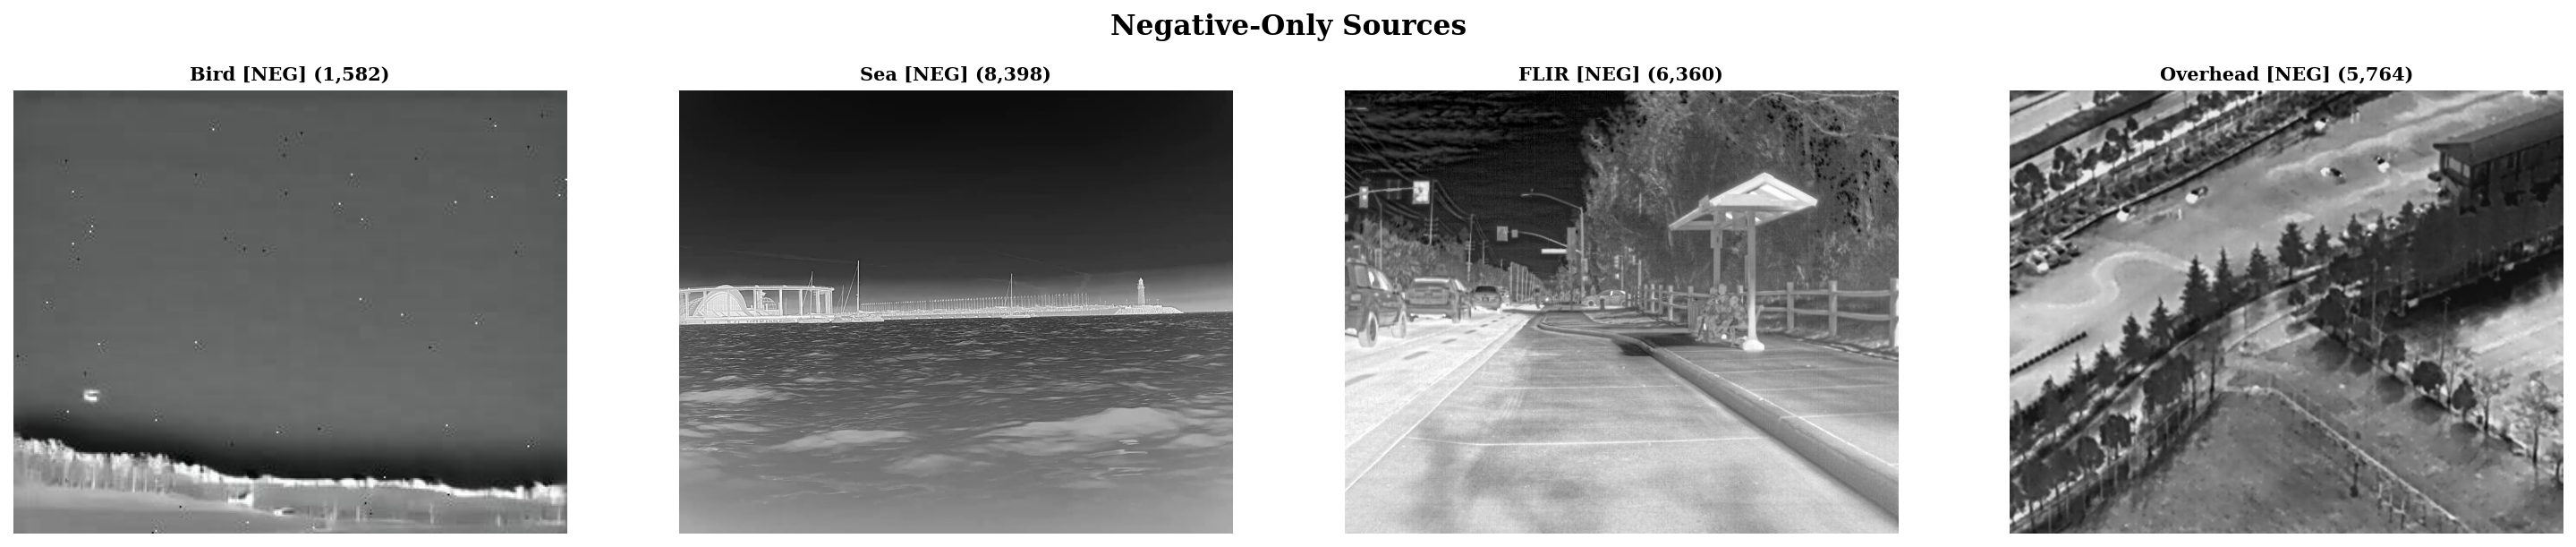

In [5]:
#  Sample Images per Source (with Ground Truth bounding boxes) 

SAMPLES_DIR = Path("../scripts/dataset_preparation/sample_images")

positive_sources = [
    ("goldv2.png",      "Gold V2 (3,687)"),
    ("may22.png",       "May22 (2,411)"),
    ("roboflow.jpg",    "Roboflow (2,269)"),
    ("smallobj.jpg",    "Small Objects (11,246)"),
    ("ddetIR.jpg",      "DroneDetect IR (185)"),
    ("3rd_antiuav.jpg", "3rd Anti-UAV (32,132)"),
    ("svanstrom.jpg",   "Svanstr\u00f6m (21,637)"),
    ("cst.jpg",         "CST Anti-UAV (22,957)"),
    ("czoom.jpg",       "Crop-Zoom (9,808)"),
    ("other.png",       "Other (694)"),
]

negative_sources = [
    ("bird.jpg",  "Bird [NEG] (1,582)"),
    ("sea.jpg",   "Sea [NEG] (8,398)"),
    ("flir.jpg",  "FLIR [NEG] (6,360)"),
    ("ovh.jpg",   "Overhead [NEG] (5,764)"),
]

def show_grid(sources, title, cols=3):
    rows = (len(sources) + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(5 * cols, 4 * rows))
    axes = axes.flatten() if rows * cols > 1 else [axes]
    fig.suptitle(title, fontsize=15, fontweight="bold", y=1.01)
    for i, ax in enumerate(axes):
        if i < len(sources):
            fname, label = sources[i]
            fpath = SAMPLES_DIR / fname
            if fpath.exists():
                ax.imshow(mpimg.imread(str(fpath)))
                ax.set_title(label, fontsize=10, fontweight="bold")
            else:
                ax.text(0.5, 0.5, f"{fname}\nnot found",
                        ha="center", va="center", transform=ax.transAxes)
                ax.set_title(label, fontsize=10)
        ax.axis("off")
    plt.tight_layout()
    plt.show()

 
print('  Sample Images per Source (with GT bounding boxes)')
 
show_grid(positive_sources, "Positive Sources", cols=3)
show_grid(negative_sources, "Negative-Only Sources", cols=4)

---
## 2. All IR Models — TEST Split Comparison

Progression of IR models as the dataset grew from 1 source to 13 sources. All metrics are **YOLO .val() metrics** (threshold-agnostic mAP, best-point P/R).

In [6]:
#  All IR Models Comparison (YOLO .val() metrics) 

comparison_data = [
    ('IR GoldV2',  'goldv2',
     3687,   0.9532, 0.9277, 0.9403, 0.9621),
    ('IR dsetV3',  'goldv2, may22, roboflow',
     8367,   0.8967, 0.7121, 0.7938, 0.7806),
    ('IR dsetV4',  '+ smallobj, ddetIR, bird',
     21380,  0.9578, 0.8971, 0.9265, 0.9518),
    ('IR dsetV5',  '+ 3rd Anti-UAV',
     53512,  0.9467, 0.8190, 0.8782, 0.8751),
    ('IR dsetV6',  '+ Svanstr\u00f6m',
     75149,  0.9445, 0.8545, 0.8972, 0.8951),
    ('IR Final',   '+ CST, czoom, sea, flir, ovh',
     129130, 0.9549, 0.9795, 0.9670, 0.9770),
]

df_comp = pd.DataFrame(comparison_data,
    columns=['Model', 'Sources', 'Images', 'Precision', 'Recall', 'F1', 'mAP@0.5'])
df_comp = df_comp.set_index('Model')

 
print('  All IR Models \u2014 TEST Split (YOLO .val() metrics)')
 
display(df_comp.style
    .format({'Images': '{:,}',
             'Precision': '{:.4f}', 'Recall': '{:.4f}',
             'F1': '{:.4f}', 'mAP@0.5': '{:.4f}'})
    .set_properties(**{'text-align': 'center'})
    .highlight_max(subset=['F1', 'mAP@0.5'],
        props='background-color: #2E7D32; color: white; font-weight: bold')
    .highlight_max(subset=['Precision'],
        props='background-color: #1565C0; color: white; font-weight: bold')
    .highlight_max(subset=['Recall'],
        props='background-color: #E65100; color: white; font-weight: bold'))

  All IR Models — TEST Split (YOLO .val() metrics)


,Sources,Images,Precision,Recall,F1,mAP@0.5
Model,,,,,,
IR GoldV2,goldv2,"3,687",0.9532,0.9277,0.9403,0.9621
IR dsetV3,"goldv2, may22, roboflow","8,367",0.8967,0.7121,0.7938,0.7806
IR dsetV4,"+ smallobj, ddetIR, bird","21,380",0.9578,0.8971,0.9265,0.9518
IR dsetV5,+ 3rd Anti-UAV,"53,512",0.9467,0.8190,0.8782,0.8751
IR dsetV6,+ Svanström,"75,149",0.9445,0.8545,0.8972,0.8951
IR Final,"+ CST, czoom, sea, flir, ovh","129,130",0.9549,0.9795,0.9670,0.9770


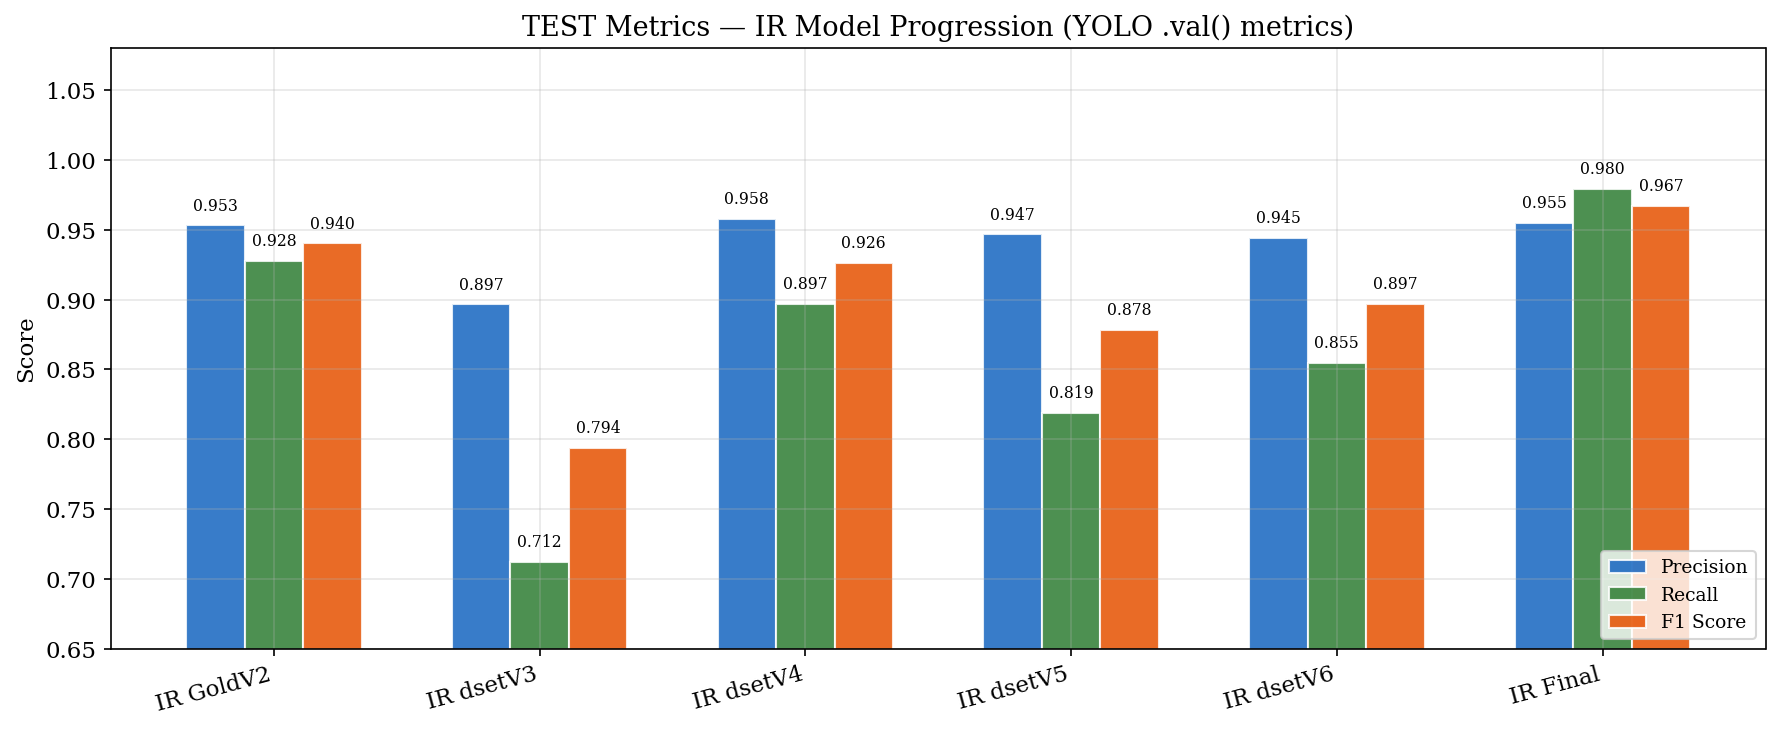

In [7]:
# === Bar chart: P, R, F1 for all models 

fig, ax = plt.subplots(figsize=(12, 5))
x = np.arange(len(df_comp))
w = 0.22
colors = ['#1565C0', '#2E7D32', '#E65100']
metrics = [('Precision', 'Precision'), ('Recall', 'Recall'), ('F1', 'F1 Score')]

for i, (col, name) in enumerate(metrics):
    bars = ax.bar(x + i*w, df_comp[col], w, label=name, color=colors[i], alpha=0.85, edgecolor='white')
    for bar, val in zip(bars, df_comp[col]):
        ax.text(bar.get_x() + bar.get_width()/2, val + 0.008, f'{val:.3f}',
                ha='center', va='bottom', fontsize=7.5)

ax.set_xticks(x + w)
ax.set_xticklabels(df_comp.index, rotation=15, ha='right')
ax.set_ylim(0.65, 1.08)
ax.set_ylabel('Score')
ax.set_title('TEST Metrics \u2014 IR Model Progression (YOLO .val() metrics)')
ax.legend(loc='lower right')
plt.tight_layout()
plt.savefig(FIGS_DIR / 'model_progression_bar.png')
plt.show()

---
## 3. IR Final Model — YOLO .val() metrics

YOLO's `.val()` computes precision, recall, and F1 at its internally-determined best confidence point, and mAP as the area under the PR curve (threshold-agnostic). These are the standard metrics for paper comparisons.

In [8]:
#  Load metrics from run directory 

run_dir = RUNS_DIR / RUN_NAME

with open(run_dir / 'metrics.json') as f:
    metrics = json.load(f)

# Val + Test side by side (YOLO .val() metrics)
rows = []
for split in ['val', 'test']:
    if split not in metrics:
        continue
    m = metrics[split]
    rows.append({
        'Split': split.upper(),
        'Precision': m['precision'],
        'Recall': m['recall'],
        'F1': m['f1'],
        'mAP@0.5': m['mAP50'],
        'mAP@0.5:0.95': m['mAP50_95'],
    })

df_detail = pd.DataFrame(rows).set_index('Split')

 
print('  IR Final Model \u2014 YOLO .val() metrics (VAL & TEST)')
 
display(df_detail.style
    .format({c: '{:.4f}' for c in df_detail.columns})
    .set_properties(**{'text-align': 'center'})
    .highlight_max(props='background-color: #2E7D32; color: white; font-weight: bold'))

  IR Final Model — YOLO .val() metrics (VAL & TEST)


,Precision,Recall,F1,mAP@0.5,mAP@0.5:0.95
Split,,,,,
VAL,0.9185,0.9555,0.9366,0.9525,0.5600
TEST,0.9549,0.9795,0.9670,0.9770,0.6020


---
## 4. Operational Threshold Sweep (T*)

### What is the threshold sweep?

YOLO .val() metrics (above) are computed at internally-determined thresholds optimised for each metric. For **deployment**, we need a single fixed confidence threshold to decide "is this a drone?"

The **threshold sweep** evaluates the model at every confidence level from 0.01 to 0.99 on the **val** split and selects the threshold T\* that **maximises F1 score**. This T\* is then frozen and applied to the **test** split for final evaluation.

At T\*, we also compute metrics YOLO does not provide:
- **TP / FP / FN** raw counts
- **Per-size breakdown** (tiny / medium / large)
- **True Negatives** (negative images correctly ignored)
- **FPPI** (false positives per image on negatives)

In [9]:
#  Operational metrics at T* 

t_star = metrics.get('val_threshold', '?')
print(f'F1-optimal threshold T* = {t_star} (selected on val split)')
print()

test_m = metrics.get('test', {})
if 'frozen_precision' in test_m:
    op_rows = [{
        'Metric': 'Precision', 'Value': test_m['frozen_precision'],
    }, {
        'Metric': 'Recall', 'Value': test_m['frozen_recall'],
    }, {
        'Metric': 'F1', 'Value': test_m['frozen_f1'],
    }]
    df_op = pd.DataFrame(op_rows).set_index('Metric')

     
    print(f'  TEST Split @ Frozen T*={t_star}')
     
    display(df_op.style.format({'Value': '{:.4f}'}).set_properties(**{'text-align': 'center'}))

    # TP / FP / FN
    print(f"\n  TP: {test_m['tp']:,}   FP: {test_m['fp']:,}   FN: {test_m['fn']:,}")
    print(f"  Total GT: {test_m['tp'] + test_m['fn']:,}")
else:
    print('No frozen threshold metrics found — run eval.py on test split first')

F1-optimal threshold T* = 0.38 (selected on val split)

  TEST Split @ Frozen T*=0.38


,Value
Metric,
Precision,0.9652
Recall,0.9695
F1,0.9673



  TP: 6,100   FP: 220   FN: 192
  Total GT: 6,292


In [19]:
# === Size Breakdown at T* ===

sf = run_dir / 'size_breakdown.json'
with open(sf) as f:
    sb = json.load(f)

sb_threshold = sb.get('threshold', '?')

# T=0.40 data (from previous eval run)
t040_test = {
    'tiny':   {'precision': 0.9488, 'recall': 0.9488, 'tp': 3357, 'fp': 181, 'fn': 181, 'gt_count': 3720},
    'medium': {'precision': 0.9900, 'recall': 0.9876, 'tp': 2466, 'fp': 25,  'fn': 31,  'gt_count': 2315},
    'large':  {'precision': 0.9693, 'recall': 0.9844, 'tp': 253,  'fp': 8,   'fn': 4,   'gt_count': 257},
}

fmt = {'Precision': '{:.4f}', 'Recall': '{:.4f}',
       'TP': '{:,}', 'FP': '{:,}', 'FN': '{:,}', 'GT Count': '{:,}'}

# --- Table 1: T*=0.38 from JSON ---
for split in ['val', 'test']:
    if split not in sb:
        continue
    rows = []
    for bucket in ['tiny', 'medium', 'large']:
        if bucket not in sb[split]:
            continue
        b = sb[split][bucket]
        rows.append({
            'Size': bucket,
            'Precision': b['precision'],
            'Recall': b['recall'],
            'TP': b['tp'], 'FP': b['fp'], 'FN': b['fn'],
            'GT Count': b['gt_count'],
        })
    df_sb = pd.DataFrame(rows).set_index('Size')
    print(f"  Size Breakdown — {split.upper()} (T* = {sb_threshold})")
    display(df_sb.style
        .format(fmt, na_rep='—')
        .background_gradient(subset=['Precision', 'Recall'], cmap='RdYlGn', vmin=0.8, vmax=1.0)
        .set_properties(**{'text-align': 'center'}))

# --- Table 2: T=0.40 (hardcoded) ---
rows_040 = []
for bucket in ['tiny', 'medium', 'large']:
    b = t040_test[bucket]
    rows_040.append({
        'Size': bucket,
        'Precision': b['precision'],
        'Recall': b['recall'],
        'TP': b['tp'], 'FP': b['fp'], 'FN': b['fn'],
        'GT Count': b['gt_count'],
    })
df_040 = pd.DataFrame(rows_040).set_index('Size')
print(f"\n  Size Breakdown — TEST (T = 0.40)")
display(df_040.style
    .format(fmt, na_rep='—')
    .background_gradient(subset=['Precision', 'Recall'], cmap='RdYlGn', vmin=0.8, vmax=1.0)
    .set_properties(**{'text-align': 'center'}))


  Size Breakdown — TEST (T* = 0.38)


,Precision,Recall,TP,FP,FN,GT Count
Size,,,,,,
tiny,0.9481,0.9553,"3,380",185,158,"3,720"
medium,0.9892,0.9880,"2,467",27,30,"2,315"
large,0.9693,0.9844,253,8,4,257



  Size Breakdown — TEST (T = 0.40)


,Precision,Recall,TP,FP,FN,GT Count
Size,,,,,,
tiny,0.9488,0.9488,"3,357",181,181,"3,720"
medium,0.9900,0.9876,"2,466",25,31,"2,315"
large,0.9693,0.9844,253,8,4,257


In [11]:
#  True Negatives at T* 

test_m = metrics.get('test', {})
val_m = metrics.get('val', {})

test_tn = test_m.get('tn', 0)
test_neg = test_m.get('neg_images', 0)
val_tn = val_m.get('tn', 0)
val_neg = val_m.get('neg_images', 0)
total_tn = test_tn + val_tn
total_neg = test_neg + val_neg
total_fp_neg = (test_m.get('fp_on_neg', 0) + val_m.get('fp_on_neg', 0))

tn_data = {
    'Split': ['Val', 'Test', 'Combined'],
    'Negative Images': [val_neg, test_neg, total_neg],
    'TN (correct)': [val_tn, test_tn, total_tn],
    'FP on Neg': [val_m.get('fp_on_neg', 0), test_m.get('fp_on_neg', 0), total_fp_neg],
    'TN Rate': [
        f"{val_tn/max(1,val_neg):.1%}",
        f"{test_tn/max(1,test_neg):.1%}",
        f"{total_tn/max(1,total_neg):.1%}",
    ],
}
df_tn = pd.DataFrame(tn_data).set_index('Split')

 
print(f'  True Negatives @ T*={sb_threshold}')
 
display(df_tn.style
    .format({'Negative Images': '{:,}', 'TN (correct)': '{:,}', 'FP on Neg': '{:,}'})
    .set_properties(**{'text-align': 'center'}))

if test_m.get('fppi'):
    print(f"\n  TEST FPPI: {test_m['fppi']:.4f}")

  True Negatives @ T*=0.38


,Negative Images,TN (correct),FP on Neg,TN Rate
Split,,,,
Val,"4,294","4,064",230,94.6%
Test,"3,355","3,309",46,98.6%
Combined,"7,649","7,373",276,96.4%



  TEST FPPI: 0.0137


---
## 5. YOLO Evaluation Curves


  Precision-Recall Curve (TEST)


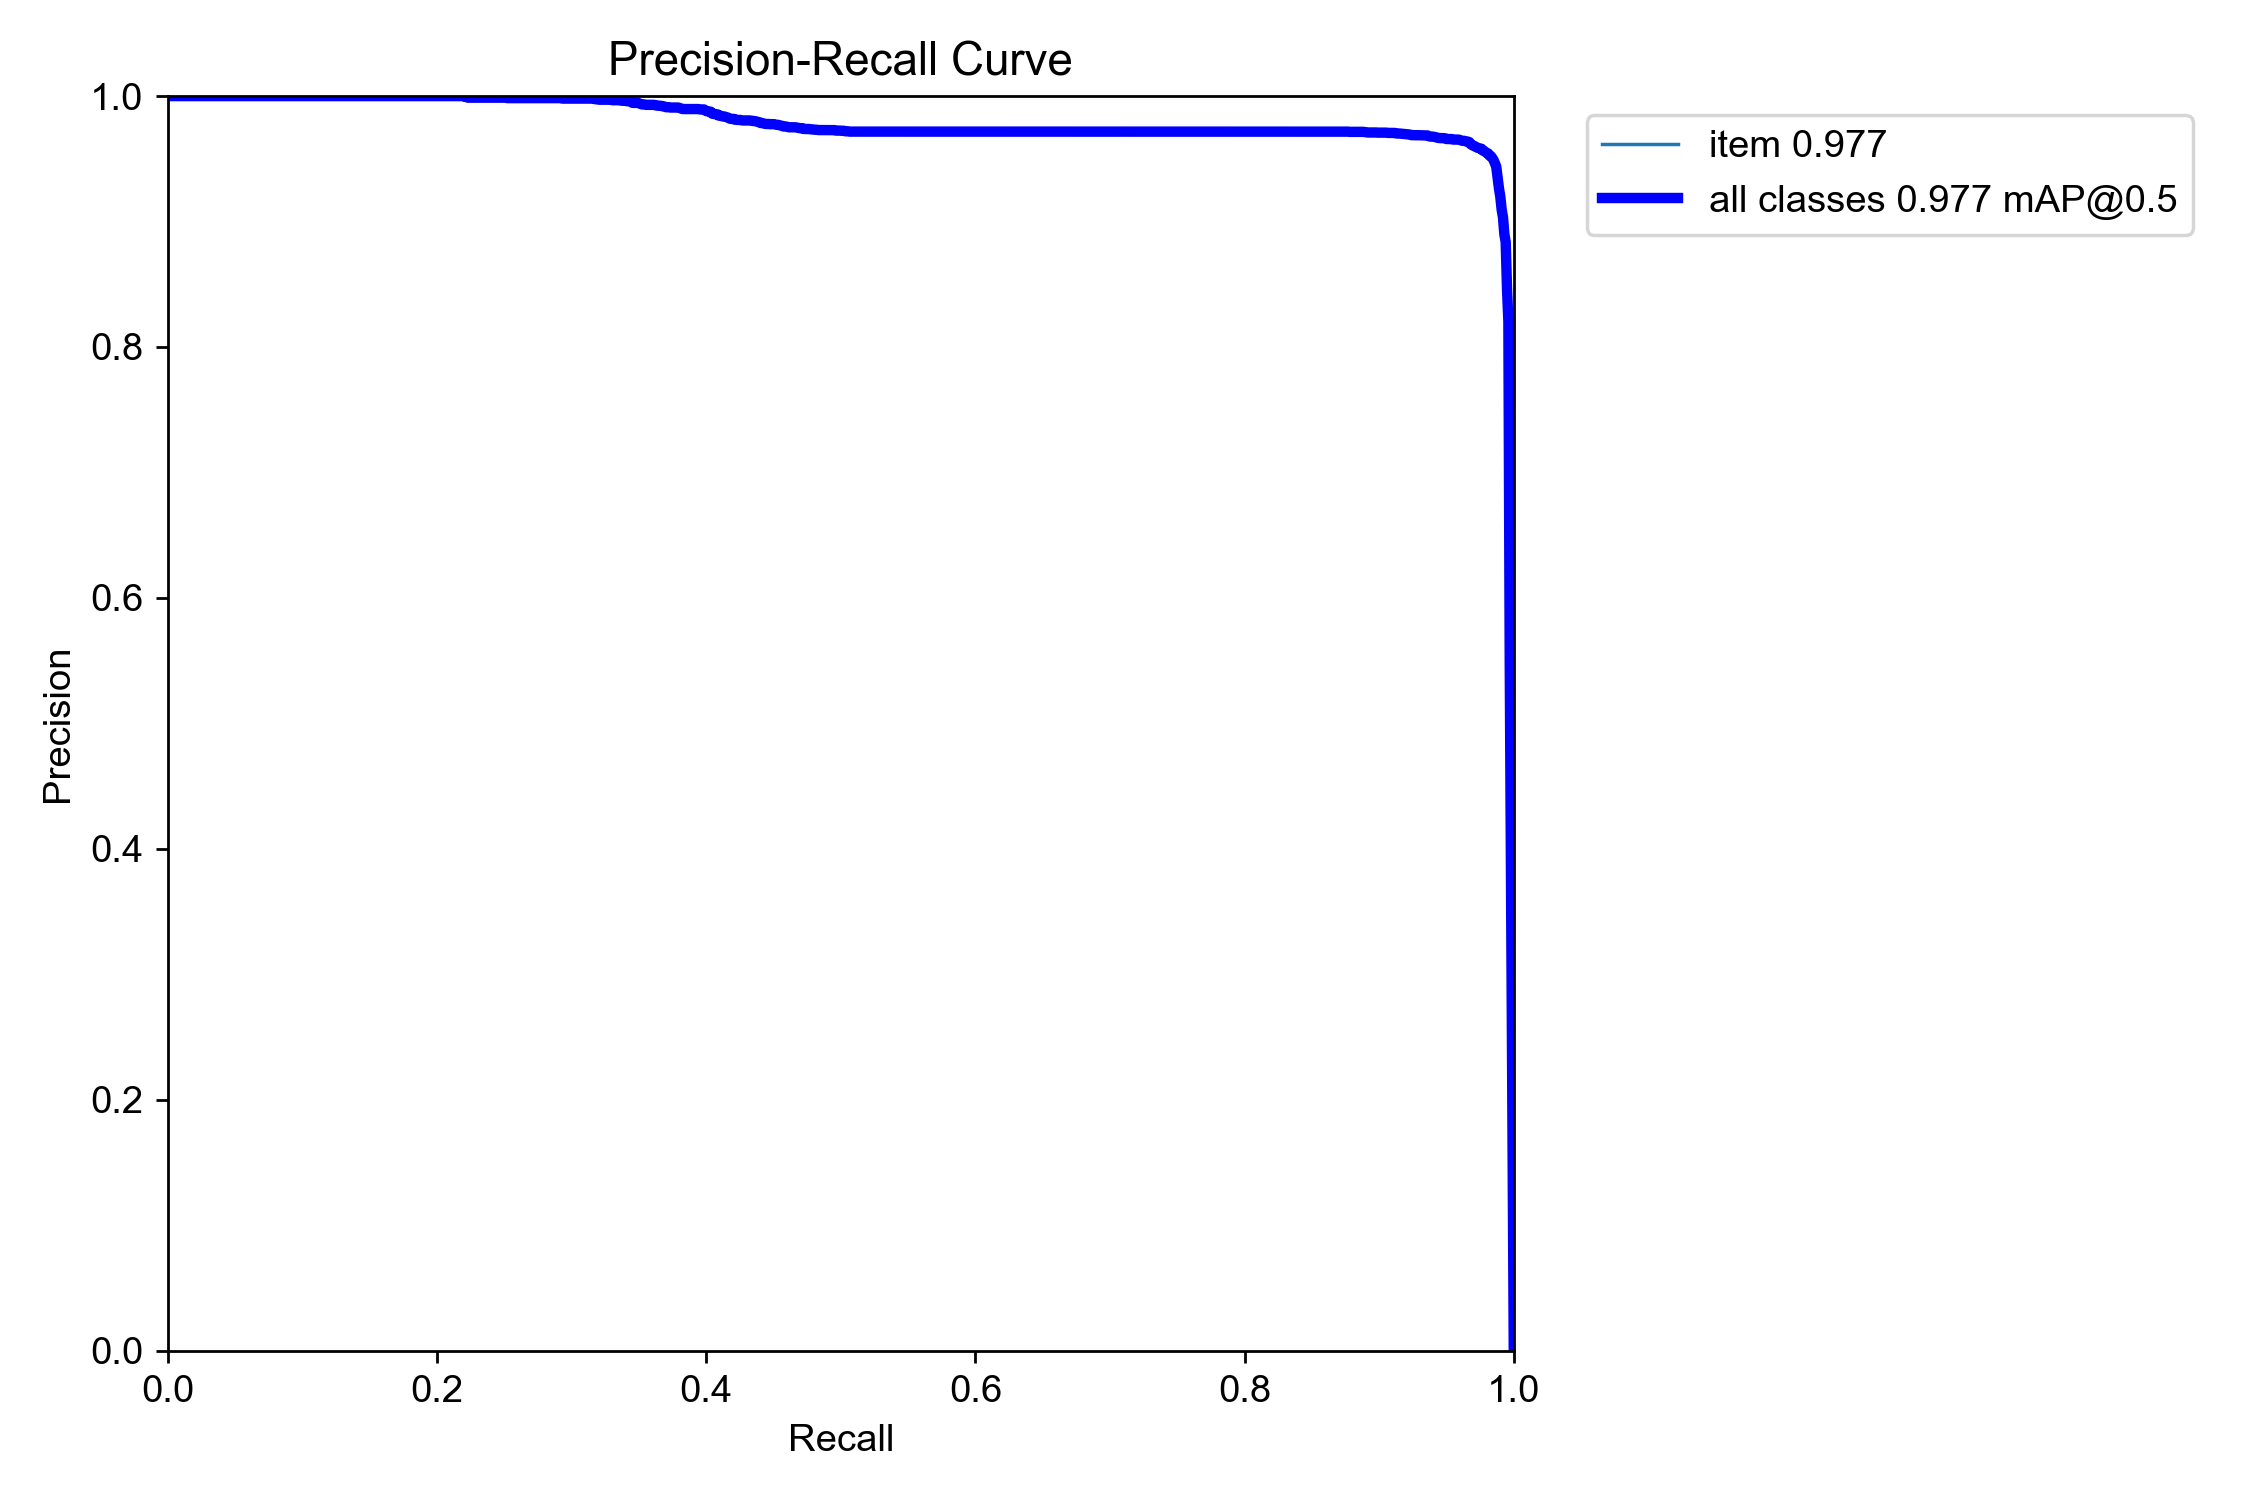


  F1-Confidence Curve (TEST)


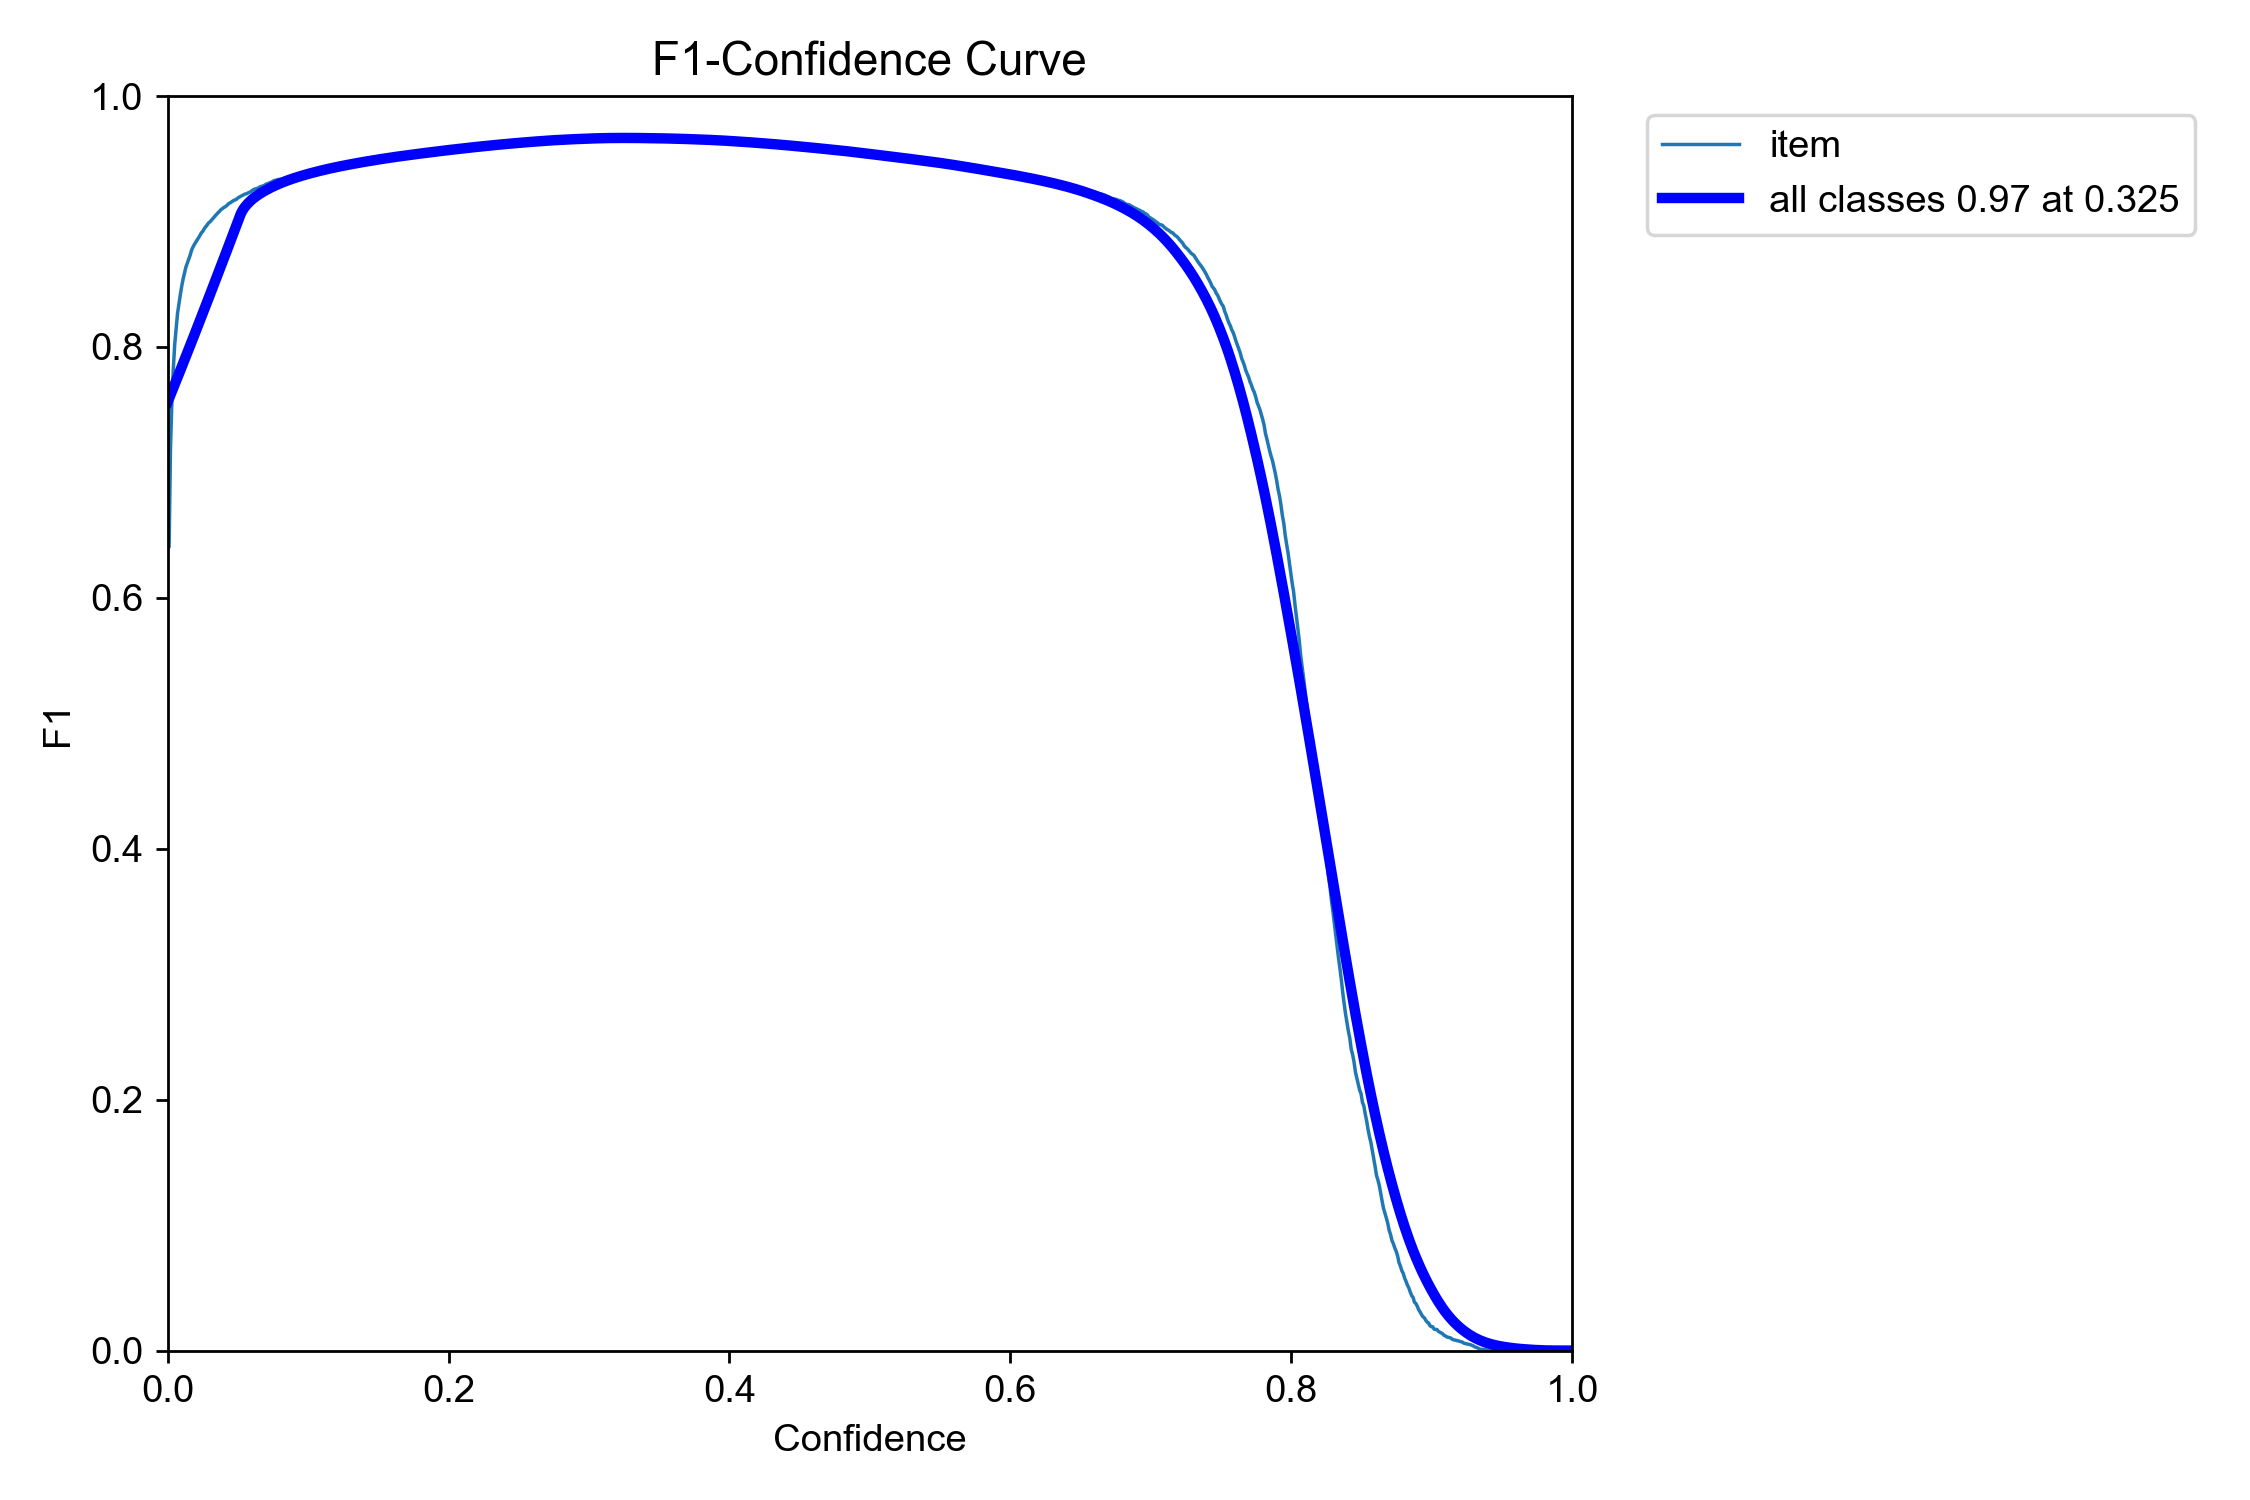


  Confusion Matrix (TEST, normalized)


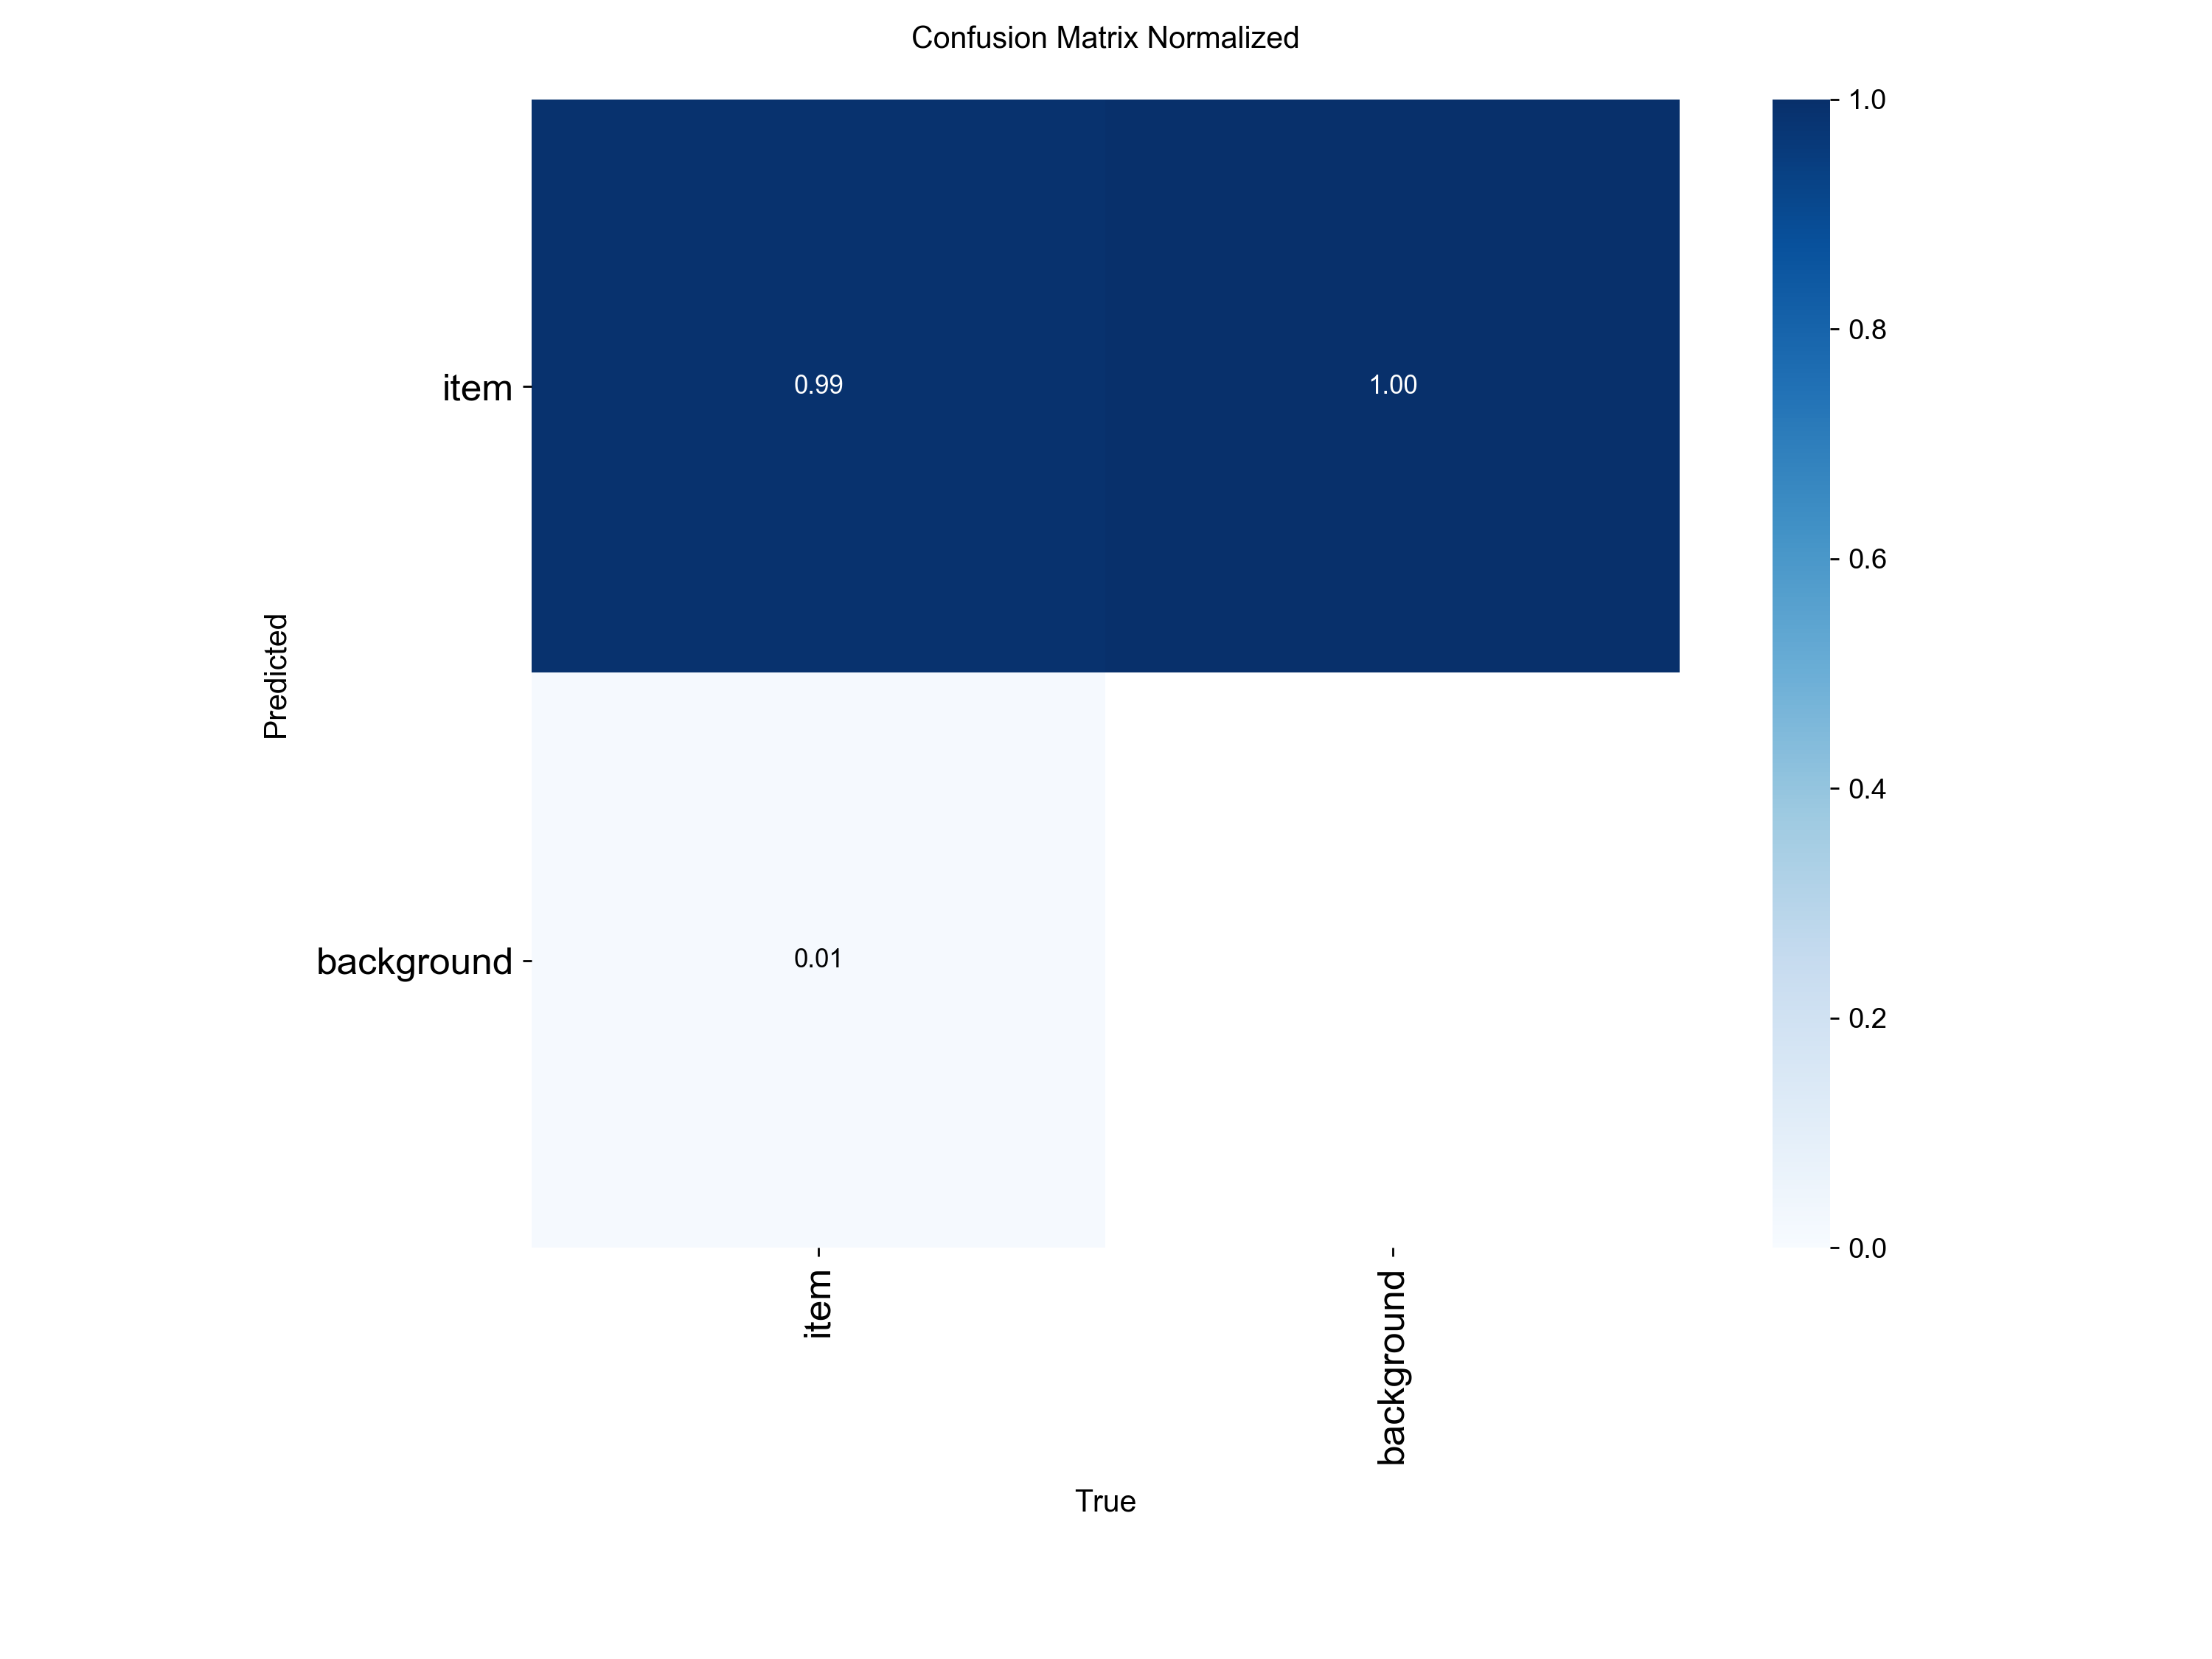

In [12]:
#  Show YOLO-generated evaluation curves 

curve_files = [
    ('yolo_test_BoxPR_curve.png', 'Precision-Recall Curve (TEST)'),
    ('yolo_test_BoxF1_curve.png', 'F1-Confidence Curve (TEST)'),
    ('yolo_test_confusion_matrix_normalized.png', 'Confusion Matrix (TEST, normalized)'),
]

for fname, title in curve_files:
    fpath = run_dir / fname
    if fpath.exists():
        print(f'\n  {title}')
        display(Image(filename=str(fpath), width=600))
    else:
        print(f'  {fname} not found')

---
## 6. Training Curves

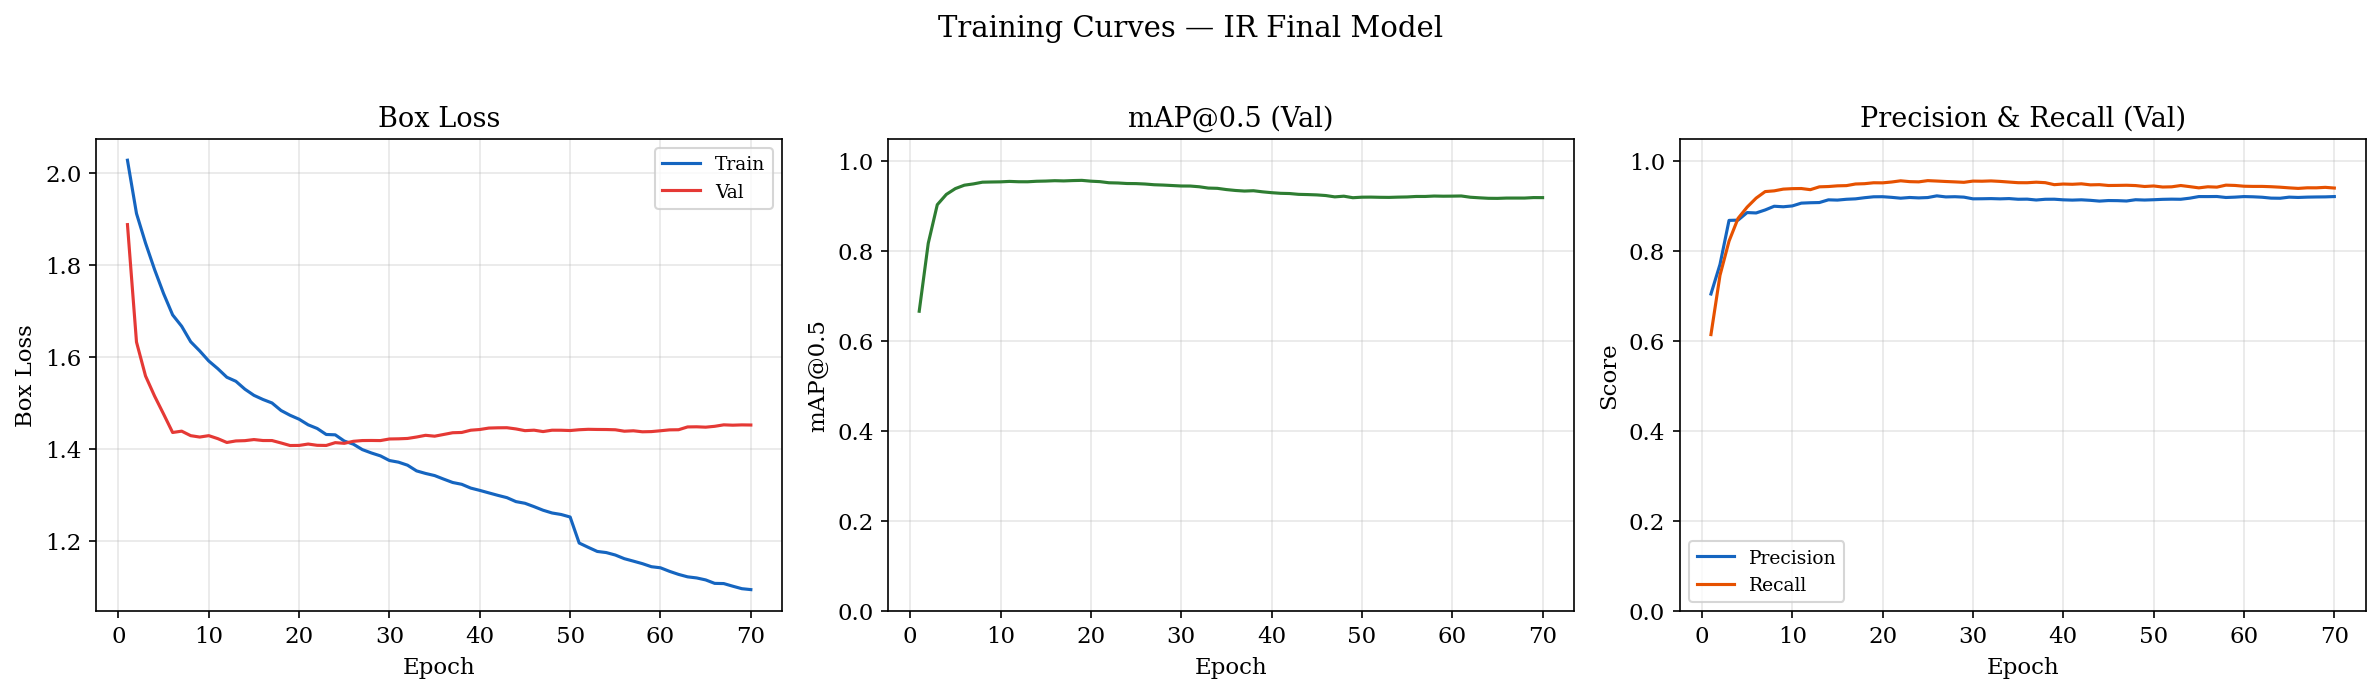

In [16]:

results_path = run_dir / 'results.csv'
if results_path.exists():
    df_train = pd.read_csv(results_path)
    df_train.columns = df_train.columns.str.strip()

    fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

    if 'train/box_loss' in df_train.columns:
        axes[0].plot(df_train['epoch'], df_train['train/box_loss'], label='Train', color='#1565C0')
        if 'val/box_loss' in df_train.columns:
            axes[0].plot(df_train['epoch'], df_train['val/box_loss'], label='Val', color='#E53935')
        axes[0].set_xlabel('Epoch')
        axes[0].set_ylabel('Box Loss')
        axes[0].set_title('Box Loss')
        axes[0].legend()

    if 'metrics/mAP50(B)' in df_train.columns:
        axes[1].plot(df_train['epoch'], df_train['metrics/mAP50(B)'], color='#2E7D32')
        axes[1].set_xlabel('Epoch')
        axes[1].set_ylabel('mAP@0.5')
        axes[1].set_title('mAP@0.5 (Val)')
        axes[1].set_ylim(0, 1.05)

    if 'metrics/precision(B)' in df_train.columns:
        axes[2].plot(df_train['epoch'], df_train['metrics/precision(B)'], label='Precision', color='#1565C0')
        axes[2].plot(df_train['epoch'], df_train['metrics/recall(B)'], label='Recall', color='#E65100')
        axes[2].set_xlabel('Epoch')
        axes[2].set_ylabel('Score')
        axes[2].set_title('Precision & Recall (Val)')
        axes[2].set_ylim(0, 1.05)
        axes[2].legend()

    plt.suptitle('Training Curves \u2014 IR Final Model', fontsize=14, y=1.02)
    plt.tight_layout()
    plt.savefig(FIGS_DIR / 'training_curves.png')
    plt.show()
else:
    print('No results.csv found')

In [20]:
# Find best.pt epoch 
df_train['fitness'] = 0.1 * df_train['metrics/mAP50(B)'] + 0.9 * df_train['metrics/mAP50-95(B)']
best_epoch = int(df_train.loc[df_train['fitness'].idxmax(), 'epoch'])
print(f"\nbest.pt saved at epoch {best_epoch}  (YOLO fitness = 0.1×mAP50 + 0.9×mAP50-95)")



best.pt saved at epoch 22  (YOLO fitness = 0.1×mAP50 + 0.9×mAP50-95)


---
## 7. Summary

| Metric | Value |
|--------|------:|
| **Dataset** | ir_dset_final (129,130 images, 13 sources) |
| **Model** | YOLO26n, 70 epochs |
| **T*** | 0.38 (F1-optimal, selected on val) |

### TEST Split — YOLO .val() vs Frozen T*

| Metric | YOLO .val() | @ T*=0.38 |
|--------|----------:|----------:|
| **Precision** | 0.9549 | 0.9652 |
| **Recall** | 0.9795 | 0.9695 |
| **F1** | 0.9670 | 0.9673 |
| **mAP@0.5** | 0.9770 | 0.9770 |
| **TP** | — | 6,100 |
| **FP** | — | 220 |
| **FN** | — | 192 |
| **TN (val+test)** | — | 7,373 / 7,649 (96.4%) |
| **FPPI** | — | 0.0137 |

run: python scripts/check_leakage.py --dataset-yaml "G:/drone/IR_dset_final/dataset.yaml"


## Data Leakage Verification

| Split | Images |
|-------|--------|
| Train | 107,809 |
| Val   | 11,709 |
| Test  | 9,612 |

### Exact Filename Collision Check
| Pair | Collisions |
|------|-----------|
| Train vs Val |  0 |
| Train vs Test |  0 |
| Val vs Test |  0 |

### Video-Level Leakage Check 

Three filename prefixes appear across splits. These are **dataset provenance prefixes** (not video names) and **Gemini entries are independent still images**, not video frames.

| Prefix | Train | Val | Test |
|--------|-------|-----|------|
| `dv5_dv4_goldV2` | 2,102 | 80 | 83 |
| `gemini_gemini_ir` | 283 | 35 | 34 |
| `gemini_med_gemini_ir` | 32 | 4 | 4 |

### Impact Assessment

Val: 119 affected / 11,709 total = 1.02%
Test: 121 affected / 9,612 total = 1.26%
Combined: 119 + 121 = 240 / 21,321 = 1.13%

| Metric | Value |
|--------|-------|
| Eval images potentially affected | 240 / 21,321 (**1.13%**) |
| Exact duplicates across splits | **0** |

**Conclusion:** Zero exact duplicates exist across any split. The heuristic flags 3 shared filename prefixes, but these reflect dataset lineage (`dv5←dv4←goldV2`) and independent still images (`gemini`), not actual video-level contamination. Even in the worst case, <1.2% of evaluation data is potentially affected. insufficient to materially influence reported metrics.
